# Project - 2
## Statistical plots & distribution analysis
1. Draw histograms, KDEs and boxplots to inspect distributions.
2. Compare distributions across groups (e.g., region A vs B).
3. Detect outliers and comment on skewness /spread.
4. Export plots and a one-paragraph interpretation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

#### Data loading & validation

In [3]:
data = pd.read_csv("distribution_data.csv")
data.head(3)

,OrderValue,Region
0,270.43,Region A
1,283.88,Region A
2,313.93,Region A


In [4]:
data.isnull().sum()

OrderValue    10
Region         0
dtype: int64

In [5]:
data.duplicated().sum()

35

### Distribution plots

Purpose of a histogram:
A histogram bins continuous data and shows the Frequency of observations within each bin. It is the most direct way to see the overall shape of a distribution whether it's unimodal/bimodal, symmetric/skewed, and roughly what range most values fall in.

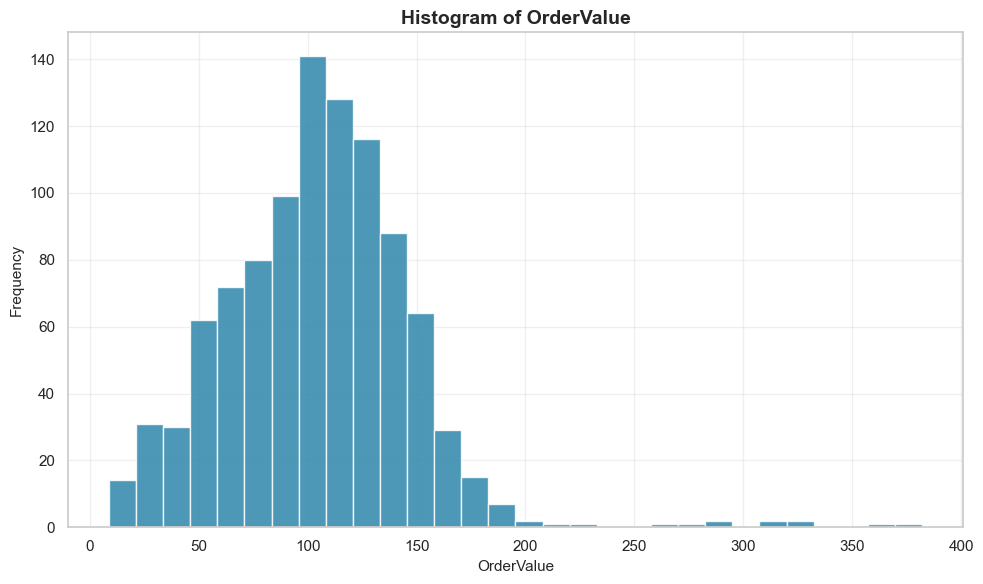

In [6]:
fig, ax = plt.subplots()
ax.hist(data['OrderValue'], bins=30, color="#2E86AB", alpha=0.85, edgecolor="white")
ax.set_title(f"Histogram of {'OrderValue'}")
ax.set_xlabel('OrderValue')
ax.set_ylabel("Frequency")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("histogram.png", dpi=150)
plt.show()
plt.close(fig)

Purpose of a KDE plot:
A KDE smooths the histogram into a continuous probability density curve. It removes the visual artifacts caused by bin-width choice in histograms, making it easier to compare the underlying SHAPE of two or more distributions directly on the same axes (e.g. group A vs B).

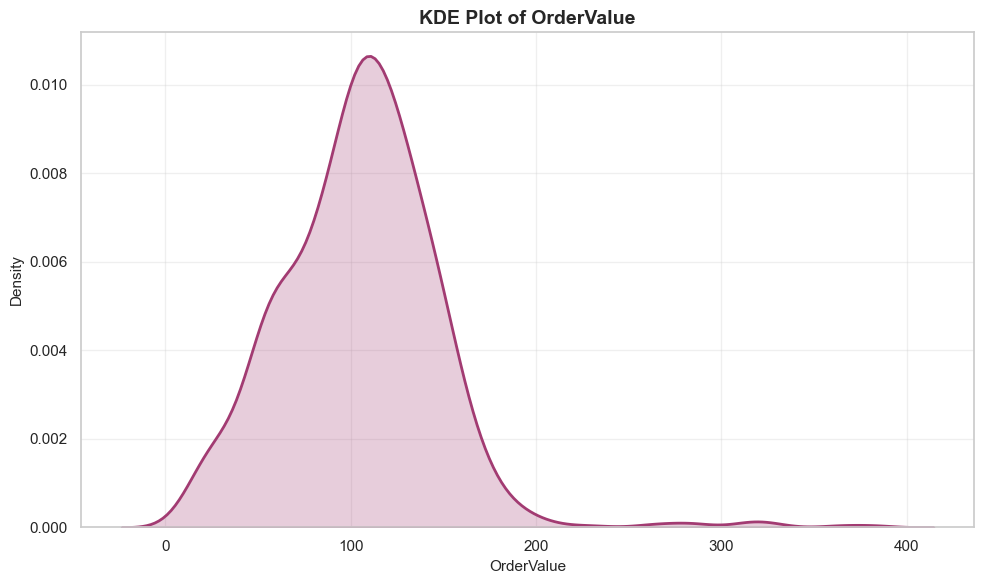

In [7]:
fig, ax = plt.subplots()
sns.kdeplot(data['OrderValue'], ax=ax, fill=True, color="#A23B72", linewidth=2)
ax.set_title(f"KDE Plot of {'OrderValue'}")
ax.set_xlabel('OrderValue')
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("kde_plot.png", dpi=150)
plt.show()
plt.close(fig)

Purpose of a BOXPlot:
A boxplot summarizes a distribution via its five-number summary (min, Q1, median, Q3, max) and flags outliers explicitly as points beyond 1.5x the interquartile range (IQR). It is the most compact way to compare SPREAD, CENTRAL TENDENCY, and OUTLIERS across multiple groups side by side.

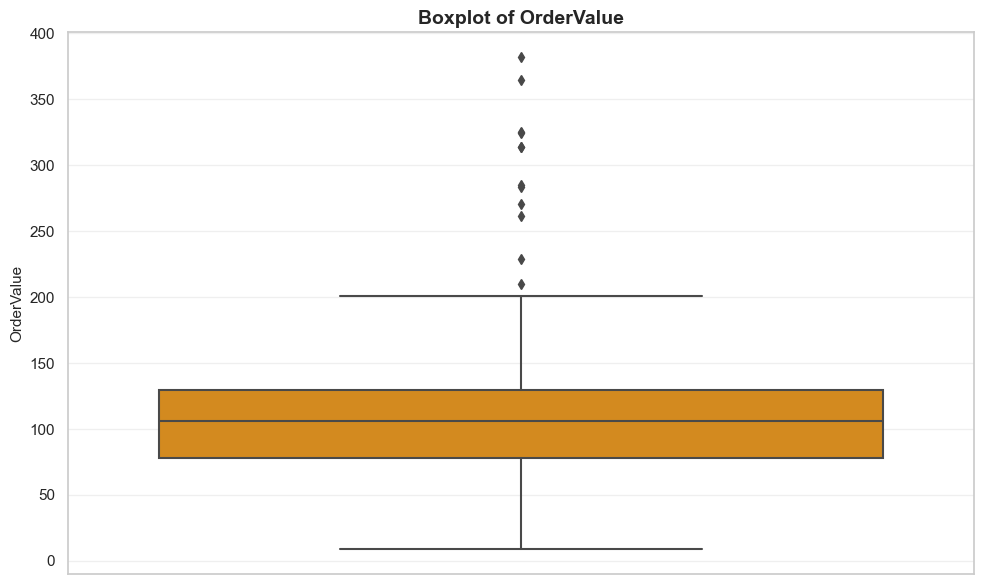

In [9]:
fig, ax = plt.subplots()
sns.boxplot(data=data, y='OrderValue', ax=ax, color="#F18F01")
ax.set_title(f"Boxplot of {'OrderValue'}")
ax.set_xlabel("")
ax.set_ylabel("OrderValue")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("boxplot.png", dpi=150)
plt.show()
plt.close(fig)

#### Outlier detection

IQR method: flag values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.
Robust to extreme values since it relies on quartiles rather than the mean/std

In [10]:
q1, q3 = data['OrderValue'].quantile(0.25), data['OrderValue'].quantile(0.75)
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(data['OrderValue'][(data['OrderValue'] < lower_bound) | (data['OrderValue'] > upper_bound)])

0      270.43
1      283.88
2      313.93
3      364.60
4      324.37
500    284.75
501    382.12
502    325.35
503    313.97
907    209.76
942    228.91
980    261.30
Name: OrderValue, dtype: float64


### Descriptive statistics

In [12]:
print('count', int(data['OrderValue'].count()))
print("mean",data['OrderValue'].mean())
print("median",data['OrderValue'].median())
print("std", data['OrderValue'].std())
print("min", data['OrderValue'].min())
print("max", data['OrderValue'].max())
print("skewness", stats.skew(data['OrderValue'], nan_policy="omit"))
print("kurtosis", stats.kurtosis(data['OrderValue'], nan_policy="omit"))  

count 990
mean 104.82169696969696
median 105.85499999999999
std 42.77070677800736
min 8.72
max 382.12
skewness 1.0557543242680265
kurtosis 5.370463925026103
